
# Extract acoustic indices from audio recordings

Acoustic indices can summarize aspects of the acoustic energy distribution in
audio recordings and are widely used to characterize animal acoustic communities[1-3].
In this example, we will see how to eficiently compute multiple acoustic indices,
and present basics post-processing posibilities. The audio recordings used in this
example can be downloaded from the open GitHub repository
(https://github.com/scikit-maad/scikit-maad/tree/production/data).


Set variables
-------------
We list all spectral and temporal acoustic indices that will be computed


In [108]:
SPECTRAL_FEATURES=['MEANf','VARf','SKEWf','KURTf','NBPEAKS','LEQf',
'ENRf','BGNf','SNRf','Hf', 'EAS','ECU','ECV','EPS','EPS_KURT','EPS_SKEW','ACI',
'NDSI','rBA','AnthroEnergy','BioEnergy','BI','ROU','ADI','AEI','LFC','MFC','HFC',
'ACTspFract','ACTspCount','ACTspMean', 'EVNspFract','EVNspMean','EVNspCount',
'TFSD','H_Havrda','H_Renyi','H_pairedShannon', 'H_gamma', 'H_GiniSimpson','RAOQ',
'AGI','nROI','aROI']

TEMPORAL_FEATURES=['ZCR','MEANt', 'VARt', 'SKEWt', 'KURTt',
               'LEQt','BGNt', 'SNRt','MED', 'Ht','ACTtFraction', 'ACTtCount',
               'ACTtMean','EVNtFraction', 'EVNtMean', 'EVNtCount']

# Parameters of the audio recorder. This is not a mandatory but it allows
# to compute the sound pressure level of the audio file (dB SPL) as a
# sonometer would do.
S = -18         # Sensbility microphone-35dBV (SM4) / -18dBV (Audiomoth)
G = 16       # Amplification gain

# Duration of the audio file that will be processed (1 min could take time, shorter duration than 30s is really faster)
chunk_duration = 30

hlim_start ='06:30' # rec7 '17:15' # rec6 '17:30' # rec4 '16:30' rec4_v2 '06:30' rec3 '06:15' rec1 '17:15' # for the spectrogram : First point on the x axis
hlim_end = '08:30' # rec7 '11:15' # rec6 '09:30 # rec4 '06:30' rec4_v2 '08:30' rec3 '09:45' rec1 '09:15'    # for the spectrogram : Last point on the x axis
flim_min = 0  #in kHz
flim_max = 16 #in kHz

SAMPLE_RATE = 36000

## Step 1 - Setup the environment
---

Get the information about the virtual machine that Google gave you

In [109]:
# get info about the virtual machine
!lscpu |grep 'Model name'
!lscpu |grep 'Core(s) per socket:'
!free -h --si | awk  '/Mem:/{print $2}'

Model name:                         13th Gen Intel(R) Core(TM) i7-13700H
Core(s) per socket:                 14
63G


### 1.1 Global settings

Change or adapt the settings :
- to import the required packages
- to set the directories and the paths
- to set some global constatns
- to set the parameters for bambird

In [110]:
# Load basic packages
# --------------------
import shutil
import numpy as np
from pathlib import Path
import datetime
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

# Parallel processing packages
# from functools import partial
from tqdm import tqdm
from concurrent import futures

import warnings
# Turn off warnings
warnings.filterwarnings("ignore")

import librosa

from maad import sound, rois, features, util
from maad.util import (plot_correlation_map, false_Color_Spectro)

from skimage.morphology import closing

In [111]:
# Define constants
# ----------------

# add shortcut to the link (https://drive.google.com/drive/folders/13OVJdujQoG5zjLwLVwC16mxUDNmGFNXb?usp=share_link)
# into your own googledrdive in order to have access to the remote folder
# !!! NEED TO BE ADAPTED TO YOU OWN CONFIG !!!
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Mock-Dataset/active/canopy_dome_10b_32khz')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Mock-Dataset/active/canopy_dome_01a_32khz')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec1dmu')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec3dmu')
ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec4dmu')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec4dmu_v2')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec6dmu')
# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/xprize/Finals-Data_without_backup/rec7dmu')

SAVE_PATH       = Path('/media/haupert/data/mes_projets/05_xprize/final')

# subsample the dataframe containing all the audio recordings
EVERY_N_ROWS = 1 # Set to 1 to keep all files.

PROCESS_DATA = False

SAVE = False

### 1.2 Define some local functions

In [112]:
#=============================================================================

def region_of_interest_index2(Sxx_power, tn, fn, 
                            seed_level=16, 
                            low_level=6, 
                            fusion_rois=(0.05, 100),
                            remove_rois_fmin_lim = 50,
                            remove_rois_fmax_lim = None,
                            remove_rain = True,
                            min_event_duration=None, 
                            max_event_duration=None, 
                            min_freq_bw=None, 
                            max_freq_bw=None, 
                            max_xy_ratio=None,
                            get_clusters=False,
                            display=False,
                            verbose=False,
                            **kwargs):

    """
    Calculates region of interest (ROI) indices based on a spectrogram.

    Parameters:
    - Sxx_power (numpy.ndarray): spectrogram with power values (Sxx_amplitude²).
    - tn (numpy.ndarray): Time axis values.
    - fn (numpy.ndarray): Frequency axis values.
    - seed_level (int): Parameter for binarization of the spectrogram (default: 16).
    - low_level (int): Parameter for binarization of the spectrogram (default: 6).
    - fusion_rois (tuple): Fusion parameters for ROIs (default: (0.05, 100)).
    - remove_rois_fmin_lim (float or tuple): Frequency threshold(s) to remove ROIs (default: None).
    - remove_rois_fmax_lim (float): Frequency threshold to remove ROIs (default: None).
    - remove_rain (bool): Whether to remove rain noise (default: True).
    - min_event_duration (float): Minimum time duration of an event in seconds (default: None).
    - max_event_duration (float): Maximum time duration of an event in seconds (default: None).
    - min_freq_bw (float): Minimum frequency bandwidth in Hz (default: None).
    - max_freq_bw (float): Maximum frequency bandwidth in Hz (default: None).
    - display (bool): Whether to display intermediate results (default: False).
    - **kwargs: Additional arguments.

    Returns:
    - nROI (int): Number of ROIs.
    - aROI (float): Percentage of ROIs area over the total area.
    - df_rois (pandas.DataFrame): DataFrame containing information about the ROIs.
    - df_clusters (pandas.DataFrame): DataFrame containing information about the clusters.

    Note:
    - This function requires the following packages: skimage, numpy, pandas, matplotlib, maad.

    """

    FUSION_ROIS = fusion_rois
    REMOVE_ROIS_FMIN_LIM = remove_rois_fmin_lim
    REMOVE_ROIS_FMAX_LIM = remove_rois_fmax_lim
    REMOVE_RAIN = remove_rain
    MIN_EVENT_DUR = min_event_duration # Minimum time duration of an event (in s)
    MAX_EVENT_DUR = max_event_duration
    MIN_FREQ_BW = min_freq_bw # Minimum frequency bandwidth (in Hz)
    MAX_FREQ_BW = max_freq_bw
    if (MIN_EVENT_DUR is not None) and (MIN_FREQ_BW is not None):  
        MIN_ROI_AREA = MIN_EVENT_DUR * MIN_FREQ_BW 
    else :
        MIN_ROI_AREA = None
    if (MAX_EVENT_DUR is not None) and (MAX_FREQ_BW is not None):  
        MAX_ROI_AREA = MAX_EVENT_DUR * MAX_FREQ_BW 
    else :
        MAX_ROI_AREA = None
    
    MAX_XY_RATIO = max_xy_ratio
    
    BIN_H = seed_level
    BIN_L = low_level

    GET_CLUSTERS = get_clusters
    
    DISPLAY = display
    EXT = kwargs.pop('ext',(tn[0], tn[-1], fn[0], fn[-1])) 

    """*********************** Convert into dB********* ********************"""
    #
    Sxx_dB = util.power2dB(Sxx_power, db_range=96) + 96

    """*********************** Remove stationnary noise ********************"""       
    #### Use median_equalizer function as it is fast reliable
    if REMOVE_RAIN: 
        # remove single vertical lines
        Sxx_dB_without_rain, _ = sound.remove_background_along_axis(Sxx_dB.T,
                                                            mode='mean',
                                                            N=1,
                                                            display=False)
        Sxx_dB = Sxx_dB_without_rain.T

    # ==================================================================================> TO COMMENT
    # remove single horizontal lines
    Sxx_dB_noNoise, _ = sound.remove_background_along_axis(Sxx_dB,
                                                    mode='median',
                                                    N=1,
                                                    display=False)
    # ==================================================================================> END TO COMMENT (change)

    Sxx_dB_noNoise[Sxx_dB_noNoise<=0] = 0
    
    """**************************** Find ROIS ******************************"""  
    # Time resolution (in s)
    DELTA_T = tn[1]-tn[0]
    # Frequency resolution (in Hz)
    DELTA_F = fn[1]-fn[0]

    # snr estimation to threshold the spectrogram
    _,bgn,snr,_,_,_ = sound.spectral_snr(util.dB2power(Sxx_dB_noNoise))
    if verbose :
        print('BGN {}dB / SNR {}dB'.format(bgn,snr))
        

    # binarization of the spectrogram to select part of the spectrogram with 
    # acoustic activity
    im_mask = rois.create_mask(
        Sxx_dB_noNoise,  
        mode_bin = 'absolute', 
        bin_h=BIN_H, 
        bin_l=BIN_L,
        # bin_h=snr+BIN_H,
        # bin_l=snr+BIN_L,
        # bin_h=util.add_dB(BIN_H,snr),
        # bin_l=util.add_dB(BIN_L,snr),
        )    
    
    if verbose :
        print('bin_h {}dB / bin_l {}dB'.format(util.add_dB(BIN_H,snr),util.add_dB(BIN_L,snr)))
        
    """**************************** Fusion ROIS ******************************"""  
    if type(FUSION_ROIS) is tuple :
        Ny_elements = round(FUSION_ROIS[0] / DELTA_T)
        Nx_elements = round(FUSION_ROIS[1] / DELTA_F)
        im_mask = closing(im_mask, footprint=np.ones([Nx_elements,Ny_elements]))

    # get the mask with rois (im_rois) and the bounding box for each rois (rois_bbox) 
    # and an unique index for each rois => in the pandas dataframe rois
    im_rois, df_rois  = rois.select_rois(
        im_mask,
        min_roi=MIN_ROI_AREA, 
        max_roi=MAX_ROI_AREA)
    
    """**************************** add a column ratio_xy ****************************"""  
    # add ratio x/y
    df_rois['ratio_xy'] = (df_rois.max_y -df_rois.min_y) / (df_rois.max_x -df_rois.min_x) 

    """************ remove some ROIs based on duration and bandwidth *****************"""  
    # remove min and max duration 
    df_rois['duration'] = (df_rois.max_x -df_rois.min_x) * DELTA_T 
    if MIN_EVENT_DUR is not None :
        df_rois = df_rois[df_rois['duration'] >= MIN_EVENT_DUR]
    if MAX_EVENT_DUR is not None :    
        df_rois = df_rois[df_rois['duration'] <= MAX_EVENT_DUR]
    df_rois.drop(columns=['duration'])

    # remove min and max frequency bandwidth 
    df_rois['bw'] = (df_rois.max_y -df_rois.min_y) * DELTA_F 
    if MIN_FREQ_BW is not None :
        df_rois = df_rois[df_rois['bw'] >= MIN_FREQ_BW]
    if MAX_FREQ_BW is not None :    
        df_rois = df_rois[df_rois['bw'] <= MAX_FREQ_BW]
    df_rois.drop(columns=['bw'])
    

    """**************************** Remove some ROIS ******************************"""  
    if len(df_rois) >0 :
        if REMOVE_ROIS_FMIN_LIM is not None:
            low_frequency_threshold_in_pixels=None
            high_frequency_threshold_in_pixels=None

            if isinstance(REMOVE_ROIS_FMIN_LIM, (float, int)) :
                low_frequency_threshold_in_pixels = max(1, round(REMOVE_ROIS_FMIN_LIM / DELTA_F))
            elif isinstance(REMOVE_ROIS_FMIN_LIM, (tuple, list, np.ndarray)) and len(REMOVE_ROIS_FMIN_LIM) == 2 :
                low_frequency_threshold_in_pixels = max(1, round(REMOVE_ROIS_FMIN_LIM[0] / DELTA_F))
                high_frequency_threshold_in_pixels = min(im_rois.shape[1]-1, round(REMOVE_ROIS_FMIN_LIM[1] / DELTA_F))
            else:
                raise ValueError ('REMOVE_ROIS_FMAX_LIM should be {None, a single value or a tuple of 2 values')

            # retrieve the list of labels that match the condition
            list_labelID = df_rois[df_rois['min_y']<=low_frequency_threshold_in_pixels]['labelID']
            # set to 0 all the pixel that match the labelID that we want to remove
            for labelID in list_labelID.astype(int).tolist() :
                im_rois[im_rois==labelID] = 0
            # delete the rois corresponding to the labelID that we removed in im_mask
            df_rois = df_rois[~df_rois['labelID'].isin(list_labelID)]

            if high_frequency_threshold_in_pixels is not None :
                # retrieve the list of labels that match the condition  
                list_labelID = df_rois[df_rois['min_y']>=high_frequency_threshold_in_pixels]['labelID']
                # set to 0 all the pixel that match the labelID that we want to remove
                for labelID in list_labelID.astype(int).tolist() :
                    im_rois[im_rois==labelID] = 0
                # delete the rois corresponding to the labelID that we removed in im_mask
                df_rois = df_rois[~df_rois['labelID'].isin(list_labelID)]

        if REMOVE_ROIS_FMAX_LIM is not None:
            if isinstance(REMOVE_ROIS_FMAX_LIM, (float, int)) :
                high_frequency_threshold_in_pixels = min(im_rois.shape[1]-1, round(REMOVE_ROIS_FMAX_LIM / DELTA_F))
            else:
                raise ValueError ('REMOVE_ROIS_FMAX_LIM should be {None, or single value')

            # retrieve the list of labels that match the condition  
            list_labelID = df_rois[df_rois['max_y']>=high_frequency_threshold_in_pixels]['labelID']
            # set to 0 all the pixel that match the labelID that we want to remove
            for labelID in list_labelID.astype(int).tolist() :
                im_rois[im_rois==labelID] = 0
            # delete the rois corresponding to the labelID that we removed in im_mask
            df_rois = df_rois[~df_rois['labelID'].isin(list_labelID)]
        
        if MAX_XY_RATIO is not None:
            df_rois = df_rois[df_rois['ratio_xy'] < MAX_XY_RATIO]  

    """**************************** Index calculation ******************************""" 

    # Convert boolean (True or False) into integer (0 or 1)
    im_mask_filtered = im_rois>0 * 1
    # number of ROIs / min
    ROI_number = len(df_rois) / (tn[-1] / 60) 
    # ROIs coverage in %
    ROI_cover = im_mask_filtered.sum() / (im_mask_filtered.shape[0]*im_mask_filtered.shape[1]) *100 

    if verbose :
        print('===> ROI_number : {:.0f}#/min | ROI_cover : {:.2f}%'.format(round(ROI_number), ROI_cover))

    """****************************************************************************""" 
    """******************************* CLUSTERING *********************************""" 
    """****************************************************************************""" 
    if GET_CLUSTERS:

        ROI_nb_clusters = 0
        ROI_shannon = None
        ROI_simpson = None
        ROI_inv_simpson = 0
        ROI_gini_simpson = None
        df_clusters = df_rois
        df_clusters['label'] = ''
        df_features = None  
        
        """****************************************************************************""" 
        """**************************** if NO CLUSTERING ******************************""" 
        """****************************************************************************""" 
    else :
        ROI_nb_clusters = None
        ROI_shannon = None
        ROI_simpson = None
        ROI_inv_simpson = None
        ROI_gini_simpson = None
        df_clusters = df_rois
        df_clusters['label'] = ''
        df_features = None

        """**************************** Display process ******************************"""

        
    LABELS = list(df_clusters['label'].unique()).sort()

    if GET_CLUSTERS :
        COLORS = ['tab:red', 'tab:green', 'tab:orange', 'tab:blue', 
                'tab:purple','tab:pink','tab:brown','tab:olive',
                'tab:cyan','tab:gray','yellowgreen','plum', 'green','darkcyan']
    else :
        COLORS = ['yellow']

    if DISPLAY : 
        fig, ax = plt.subplots(4,1,figsize=(6/10*tn[-1],8), sharex=True)
        # util.plot_wave(wave, fs,  xlabel='', ax=ax[0])
        # util.plot_wave(env, fs, ax=ax[1])
        # util.plot_spectrum(pxx, fidx, ax=ax[2])
        util.plot_spectrogram(Sxx_power, extent=EXT, ax=ax[0], ylabel ='', xlabel='', colorbar=False)
        util.plot_spectrogram(Sxx_dB_noNoise, log_scale=False, vmax = np.percentile(Sxx_dB_noNoise,99.9), vmin = np.percentile(Sxx_dB_noNoise,0.1), ylabel ='', xlabel='', extent=EXT, ax=ax[1], colorbar=False)
        # util.plot_spectrogram(Sxx_dB_noNoise_norain, log_scale=False, vmax = np.percentile(Sxx_dB_noNoise_norain,99.9), vmin = np.percentile(Sxx_dB_noNoise_norain,0.1), xlabel='', extent=EXT, ax=ax[3], colorbar=False)
        # util.plot2d(im_mask, ylabel ='', xlabel='', extent=EXT, ax=ax[3], colorbar=False)
        util.plot2d(im_mask, ylabel ='', xlabel='', extent=EXT, ax=ax[2], colorbar=False)
        # util.plot2d(im_rois, ylabel ='', xlabel='', extent=EXT, cmap = util.rand_cmap(len(df_rois), seed=1), interpolation = 'none', ax=ax[5], colorbar=False)
        util.plot_spectrogram(Sxx_power, ylabel ='', extent=EXT, ax=ax[3], colorbar=False)
        if len(df_clusters) > 0 :
            util.overlay_rois(im_ref=Sxx_power, 
                        rois = df_clusters,
                        ylabel ='', 
                        extent=EXT, 
                        ax=ax[3], 
                        colorbar=False,
                        unique_labels=LABELS,
                        edge_color=COLORS,
                        textbox_label=True)

            
    return ROI_number, ROI_cover, ROI_nb_clusters, ROI_shannon, ROI_simpson, ROI_inv_simpson, ROI_gini_simpson, df_features, df_clusters 

In [113]:
def single_file_processing(audio_full_filename, date_time):

    _, filename_with_ext = os.path.split(audio_full_filename)
    file = os.path.splitext(filename_with_ext)[0]

    # print('\n**************************************************************')
    # print(file)

    # Load the original sound (16bits) and get the sampling frequency fs
    # try:
    wave, fs = sound.load(
        filename=audio_full_filename,
        channel='left', 
        detrend=True, 
        verbose=False
        )
    

    """ ===================================================================
                    Computation in the time domain 
    ==================================================================="""

    # compute all the audio indices and store them into a DataFrame
    # dB_threshold and rejectDuration are used to select audio events.
    df_audio_ind = features.all_temporal_alpha_indices(
        wave, fs,
        mode='fast',
        Nt=512,
        gain=16,
        sensibility=-18,
        Vadc=2,
        dt=1,
        dB_threshold=3,
        rejectDuration=0.01,
        verbose=False,
        display=False
        )

    # Test if the audio clip
    if ((wave.max() >= 0.99) or (wave.min() <= -0.99)):
        clip = 1
    else:
        clip = 0
        
    df_audio_ind.insert(
        loc=0, 
        column='clipping', 
        value=clip
        )
    
    df_audio_ind.insert(
        loc=1, 
        column='audio_duration', 
        value=len(wave) / fs /60
        )

    """ ==================================================================
                    Computation in the frequency domain 
    ==================================================================="""

    # Compute the Power Spectrogram Density (PSD) : Sxx_power
    Sxx_power, tn, fn, ext = sound.spectrogram(
        wave,fs,
        window='hann',
        nperseg=1024,
        noverlap=512,
        verbose=False,
        display=False,
        savefig=None)

    # compute all the spectral indices and store them into a DataFrame
    # flim_low, flim_mid, flim_hi corresponds to the frequency limits in Hz
    # that are required to compute somes indices (i.e. NDSI)
    # if R_compatible is set to 'soundecology', then the output are similar to
    # soundecology R package.
    df_spec_ind, df_indices_per_bin = features.all_spectral_alpha_indices(
        Sxx_power,
        tn, fn,
        flim_low=[0, 1000],
        flim_mid=[1000, 6000],
        flim_hi=[6000, 16000],
        R_compatible='soundecology',
        verbose=False,
        display=False)
    
    """ ==================================================================
            Computation of the nROI (need resampling at 44.1kHz) 
    ==================================================================="""

    # resample to SAMPLING_FREQUENCY and update fs
    wave = sound.resample(
        s=wave,
        fs=fs,
        target_fs=44100,
        )
    fs = 44100
    duration = len(wave) / fs

    # Compute the Power Spectrogram Density (PSD) : Sxx_power
    Sxx_power, tn, fn, ext = sound.spectrogram(
        wave,fs,
        window='hann',
        nperseg=1024,
        noverlap=512,
        verbose=False,
        display=False,
        savefig=None)
    
    nROI, aROI, _, _, _, _, _, _, _ = region_of_interest_index2(
        Sxx_power, tn, fn,   
        seed_level=13, 
        low_level=6, 
        fusion_rois=[0.05, 100],
        remove_rois_fmin_lim = 50,
        remove_rois_fmax_lim = None,
        remove_rain = True,
        min_event_duration=0.025, 
        max_event_duration=None, 
        min_freq_bw=50, 
        max_freq_bw=None, 
        max_xy_ratio = 10,
        display = False)

    df_rois_ind = pd.DataFrame({'nROI' : [nROI], 
                                'aROI':[aROI], 
                                })

    df_spec_ind = pd.concat([df_spec_ind,
                            df_rois_ind], axis=1)
    
    """ ===================================================================
                    Create a dataframe 
    ===================================================================="""        
    # add scalar indices into the df_indices dataframe
    df_indices = pd.concat([df_audio_ind,
                            df_spec_ind], axis=1)

    # add date and audio_path
    df_indices.insert(0, 'Date', date_time)
    df_indices.insert(1, 'file', audio_full_filename)

    # add date and audio_path
    df_indices_per_bin.insert(0, 'Date', date_time)
    df_indices_per_bin.insert(1, 'file', audio_full_filename)

        
    return df_indices, df_indices_per_bin

In [114]:
# To convert the filename into date
def date_from_filename (filename) :
  # filename with format 'XXXX_yyyymmdd_hhmmss.wav'
  # extract year, month, day, hour, minute and second from the filename
  # notice the underscore _ which splits the filename into several parts
  year = int(filename.split('_')[1][0:4])
  month = int(filename.split('_')[1][4:6])
  day = int(filename.split('_')[1][6:8])
  hour = int(filename.split('_')[2][0:2])
  minute = int(filename.split('_')[2][2:4])
  #second = int(filename.split('_')[2][4:6])
  second = 00

  # create a datetime object from the extracted parameters
  date = datetime.datetime(year, month, day, hour, minute, second)

  return date

## Step 2 - Process audio
---


### Grab audio
First, we parse the directory /indices in order to get a DataFrame with date
and fullfilename. As the data was collected with a SM4 audio recording device,
we set the dateformat agument to 'SM4' in order to be able to parse the date
from the filename. In case of Audiomoth, the date is coded as Hex in the
filename.



In [115]:
# Grab audio
# -------------------
df = util.date_parser(str(ARCHIVE_PATH))

# reset index Date
df = df.reset_index()

# print the number of audio recordings
print("The number of audio recordings is %d" %len(df))


The number of audio recordings is 419


Subsamples the dataframe in order to make quick tests

In [116]:
# Keep rows every N rows
df = df.iloc[::EVERY_N_ROWS, :]

# print the number of audio recordings
print("The number of audio recordings that will be processed is %d" %len(df))

The number of audio recordings that will be processed is 419


Load and preprocess audio
-------------------------
Then we process all the files found in the directory /indices.
Initialisation of an empty dataframe df_spl to store all the dB SPL values
extracted from the whole audio dataset.



In [117]:
if PROCESS_DATA :
    
    """ ===========================================================================
                    Multi CPU
    ============================================================================"""
    # At least 2 CPUs will be used in parallel and the files to process will be 
    # distributed on each CPU depending on their availability. This will speed up
    # the process.

    # create an empty dataframe. It will contain all indices for each
    # audio file in the directory
    df_indices          = pd.DataFrame()
    df_indices_per_bin  = pd.DataFrame()

    # Number of CPU used for the calculation. 
    nb_cpu = np.max([2, os.cpu_count()])

    tic = time.perf_counter()
    # Multicpu process
    with tqdm(total=len(df), desc="multi cpu indices calculation...") as pbar:
        with futures.ProcessPoolExecutor(max_workers=nb_cpu-1) as pool:
            # give the function to map on several CPUs as well its arguments as 
            # as list
            for df_indices_temp, df_indices_per_bin_temp in pool.map(
                    single_file_processing, 
                    df["file"].to_list(), 
                    df["Date"].to_list()
                    ):
                pbar.update(1)
                df_indices = pd.concat([df_indices, df_indices_temp], axis=0)
                df_indices_per_bin = pd.concat([df_indices_per_bin, df_indices_per_bin_temp], axis=0)
    
    df_indices.set_index('Date', inplace=True)
    df_indices_per_bin.set_index('Date', inplace=True)
    
    toc = time.perf_counter()
    
    # time duration of the process
    multicpu_duration = toc - tic

    print(f"Elapsed time is {multicpu_duration:0.1f} seconds")   
    

## Save the results

In [118]:
if SAVE == True:
    # save
    filename = ARCHIVE_PATH.stem + '_indices.csv'
    df_indices.to_csv(SAVE_PATH / filename, index=True)

    filename = ARCHIVE_PATH.stem + '_indices_per_bins.csv'
    df_indices_per_bin.to_csv(SAVE_PATH / filename, index=True)

Display results
---------------
After calculating all alpha indices (in audio and spectral domain), let's have a look to the data. First, plot correlation map of all indices. We set the R threshold to 0 in order to have everything. If you want to focus on highly correlated indices set the threshold to 0.75 for instance.



In [119]:
# load the csv
filename = ARCHIVE_PATH.stem + '_indices.csv'
df_indices = pd.read_csv(SAVE_PATH / filename) #, index_col = 'Date')
df_indices = df_indices.astype({'Date': 'datetime64[ns]'})
df_indices.set_index('Date', inplace = True)

filename = ARCHIVE_PATH.stem + '_indices_per_bins.csv'
df_indices_per_bin= pd.read_csv(SAVE_PATH / filename) #, index_col = 'Date')
df_indices_per_bin = df_indices_per_bin.astype({'Date': 'datetime64[ns]'})
df_indices_per_bin.set_index('Date', inplace = True)


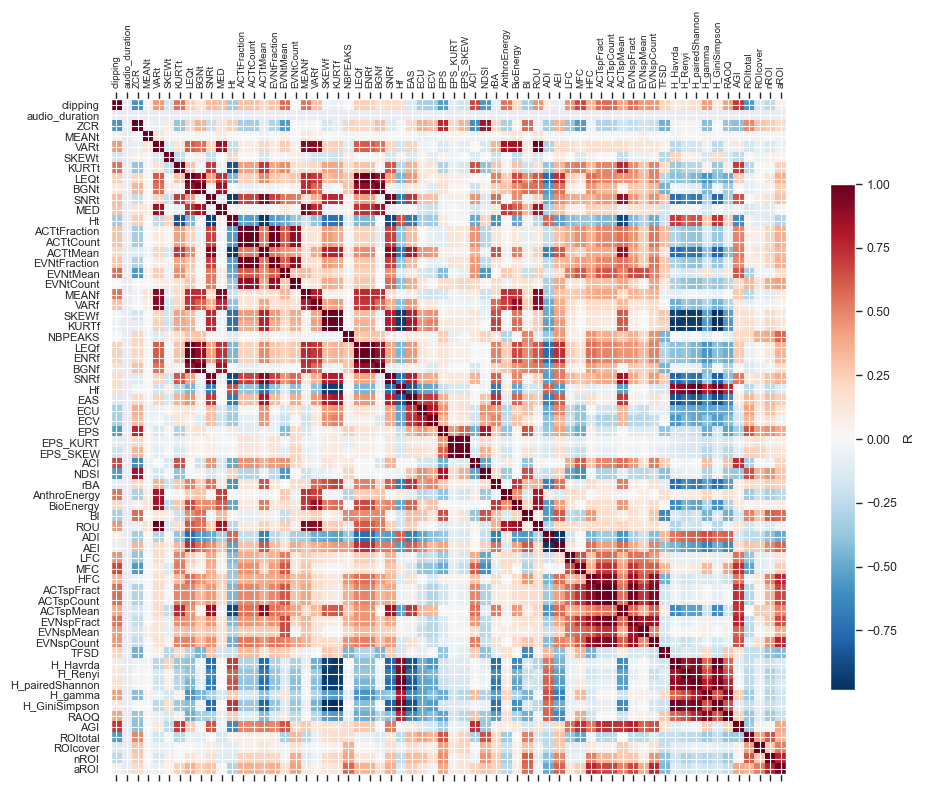

In [120]:
fig, ax = plot_correlation_map(df_indices, R_threshold=0)

A graphical way to have a quick overview of the indices variation during a 24h cycle consists in plotting heatmaps of indices For a better view, we seperate spectral and audio indices.



SPECTRAL_FEATURES

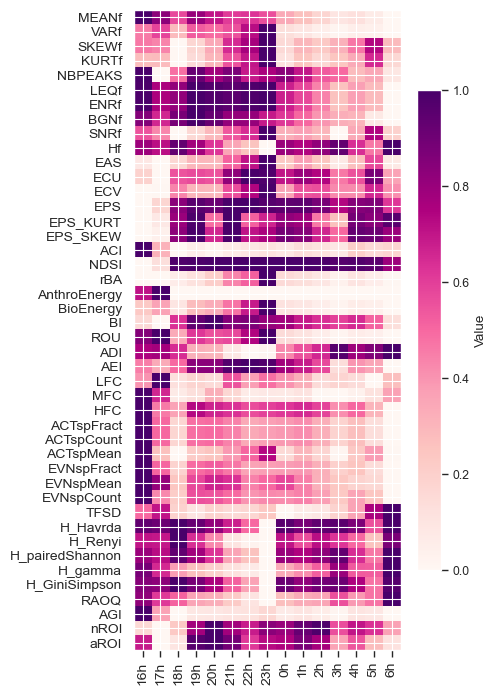

In [121]:
# Mean values by hour
df_indices_mean = df_indices[SPECTRAL_FEATURES].groupby(df_indices[SPECTRAL_FEATURES].index.hour).mean()

# normalize each indice
df_indices_mean= df_indices_mean.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# rearrange the hour
df_indices_part1 = df_indices_mean[df_indices_mean.index >= 16]
df_indices_part1.sort_index(ascending = True, inplace=True)
df_indices_part2 = df_indices_mean[df_indices_mean.index < 16]
df_indices_part2.sort_index(inplace=True)
df_indices_sorted = pd.concat([df_indices_part1, df_indices_part2], axis=0)

# Get the list of unique index of type 'hour'
x_label = [i + j for i, j in zip(map(str, df_indices_sorted.index.values), ["h"] * len(df_indices_sorted))]

# kwargs
# plt.style.use('ggplot')
cmap = "RdPu"

# plot
fig = plt.figure(figsize=(len(df_indices_sorted)*0.33, len(list(df_indices_sorted))*0.16))
ax = fig.add_subplot(111)
caxes = ax.matshow(df_indices_sorted.transpose(), cmap=cmap, aspect="auto")

fig.colorbar(caxes, shrink=0.75, label="Value")
# Set ticks on both sides of axes on
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
# We want to show all ticks...
ax.set_yticks(np.arange(len(df_indices_sorted.columns)))
ax.set_xticks(np.arange(len(x_label)))
# ... and label them with the respective list entries
ax.set_yticklabels(df_indices_sorted.columns)
ax.set_xticklabels(x_label)
# Rotate the tick labels and set their alignment.
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=90, ha="center", fontsize=10)
fig.tight_layout()
plt.show()

TEMPORAL_FEATURES

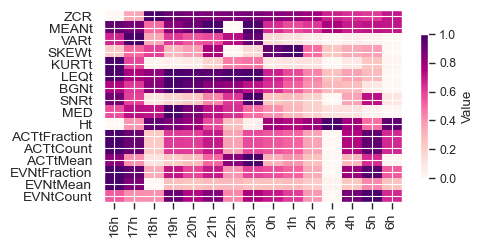

In [122]:
# Mean values by hour
df_indices_mean = df_indices[TEMPORAL_FEATURES].groupby(df_indices[TEMPORAL_FEATURES].index.hour).mean()

# normalize each indice
df_indices_mean= df_indices_mean.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# rearrange the hour
df_indices_part1 = df_indices_mean[df_indices_mean.index >= 16]
df_indices_part1.sort_index(ascending = True, inplace=True)
df_indices_part2 = df_indices_mean[df_indices_mean.index < 16]
df_indices_part2.sort_index(inplace=True)
df_indices_sorted = pd.concat([df_indices_part1, df_indices_part2], axis=0)

# Get the list of unique index of type 'hour'
x_label = [i + j for i, j in zip(map(str, df_indices_sorted.index.values), ["h"] * len(df_indices_sorted))]

# kwargs
# plt.style.use('ggplot')
cmap = "RdPu"

# plot
fig = plt.figure(figsize=(len(df_indices_sorted)*0.33, len(list(df_indices_sorted))*0.16))
ax = fig.add_subplot(111)
caxes = ax.matshow(df_indices_sorted.transpose(), cmap=cmap, aspect="auto")

fig.colorbar(caxes, shrink=0.75, label="Value")
# Set ticks on both sides of axes on
ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
# We want to show all ticks...
ax.set_yticks(np.arange(len(df_indices_sorted.columns)))
ax.set_xticks(np.arange(len(x_label)))
# ... and label them with the respective list entries
ax.set_yticklabels(df_indices_sorted.columns)
ax.set_xticklabels(x_label)
# Rotate the tick labels and set their alignment.
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=10)
plt.setp(ax.get_xticklabels(), rotation=90, ha="center", fontsize=10)
fig.tight_layout()
plt.show()

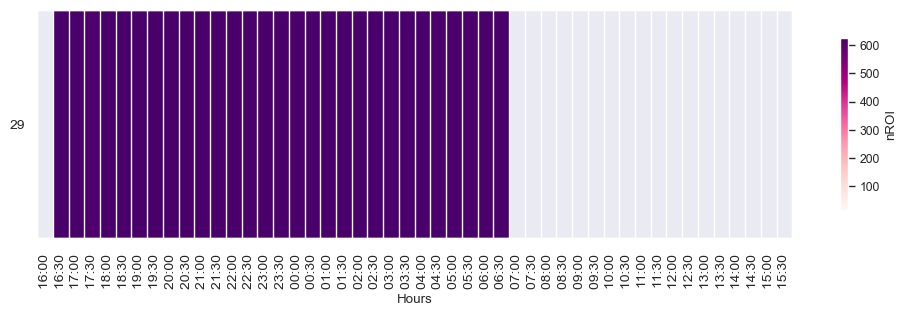

In [124]:
# rename index
df_indices.index.names = ['date']

# convert in to species richness
df_indices['n_species'] = df_indices['nROI']*0.009

df_indices_mean, _, fig, ax= util.heatmap_by_date_and_time(df_indices, 
                            disp_column='nROI',
                            time_resolution='30T',
                            full_display=True,
                            date_min_to_disp=29,
                            date_max_to_disp=29,
                            start_hour="16:00",
                            ylabel='',
                            figsize=(10,3.25),
                            vmax=20
                            )


# go back to initial name
df_indices.index.names = ['Date']

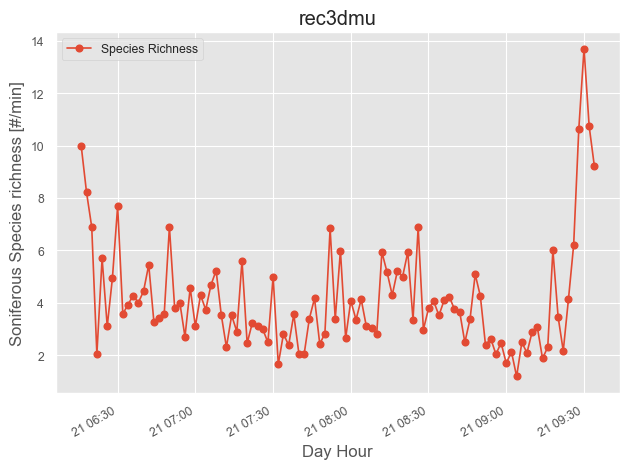

In [57]:
# Plot the Series with index
plt.style.use('ggplot')

df_n_species = df_indices.copy()

# convert in to species richness
df_n_species['n_species'] = df_indices['nROI']*0.009

df_n_species['n_species'].plot(marker='o')

# df_n_species = df_n_species.rolling('1min', min_periods=5).mean()

# # Set x-axis ticks and labels
# plt.xticks(range(len(df_indices['nROI'].index)), df_indices['nROI'].index)
# # Rotate x-axis labels if needed
# plt.xticks(rotation=90)

# Set labels and title
plt.xlabel('Day Hour')
plt.ylabel('Soniferous Species richness [#/min]')
plt.title(str(ARCHIVE_PATH.stem))
plt.legend(['Species Richness'])
           
# Set the y-axis limits
# plt.ylim(40,70)

# Show the plot
plt.tight_layout()
plt.show()

Create false color spectrograms with 3 indices

In [58]:
filtered_df = pd.concat([df_indices_per_bin[df_indices_per_bin.index.time >= pd.Timestamp(hlim_start).time()],
                        df_indices_per_bin[df_indices_per_bin.index.time <= pd.Timestamp(hlim_end).time()]], axis = 0)

In [59]:
list(filtered_df)

['file',
 'frequencies',
 'LTS',
 'MEANt_per_bin',
 'VARt_per_bin',
 'SKEWt_per_bin',
 'KURTt_per_bin',
 'LEQf_per_bin',
 'ENRf_per_bin',
 'BGNf_per_bin',
 'SNRf_per_bin',
 'Ht_per_bin',
 'ACI_per_bin',
 'ROU_per_bin',
 'ACTspFract_per_bin',
 'ACTspCount_per_bin',
 'EVNspFract_per_bin',
 'EVNspMean_per_bin',
 'EVNspCount_per_bin',
 'AGI_per_bin']

In [60]:
# # Create a vector of hours from hlim_start to 11:59 PM
# range1 = pd.date_range(start=hlim_start, end='23:59', freq='H').strftime('%H:%M')

# # Create a vector of hours from 00:00 AM to hlim_end
# range2 = pd.date_range(start='00:15', end=hlim_end, freq='H').strftime('%H:%M')

# # Concatenate the two ranges
# hours = list(range1) + list(range2)

""" 
        in case of the same day (rec3dmu)
"""
# Create a vector of hours from hlim_start to 11:59 PM
range1 = pd.date_range(start=hlim_start, end=hlim_end, freq='H').strftime('%H:%M')

# Concatenate the two ranges
hours = list(range1)


In [61]:
hours

['06:30', '07:30', '08:30']

(array([0, 1, 2]),
 [Text(0, 0, '06:30'), Text(1, 0, '07:30'), Text(2, 0, '08:30')])

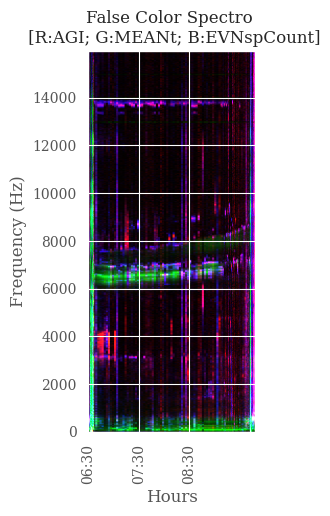

In [62]:
fcs, triplet = false_Color_Spectro(filtered_df,
                                   indices = [
                                          'AGI_per_bin',
                                          'MEANt_per_bin',
                                          'EVNspCount_per_bin',
                                              ],
                                   reverseLUT=False,
                                   unit='hours',
                                   permut=False,
                                   display=True,
                                   figsize=(2.75,5)) # rec3 (3.75,5) rec4(10.5,5) rec4_v2 (2.75, 5) rec6 (12.5,5) rec7 (14, 5)

# Set x-axis ticks and labels
plt.xticks(range(len(hours)), hours)

# Rotate x-axis labels if needed
plt.xticks(rotation=90)
